# BraTS 2021: first training input-target pair

Run from the repository root with the project's training environment and `matplotlib` installed.
Set `DATA_DIR` to the parent of `Train`, `Val`, and `Test`.

This displays T1 ? T2 from the first subject (sorted ID) in `Train`, using the
training crop and normalization. The crop is seeded for repeatability; the first
pair is slice 0 of that sampled slab, not necessarily slice 0 of the full volume.

In [1]:
import os
from pathlib import Path

# Device environment
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Defaults match the repository's train script; change for your machine.
DATA_DIR = Path("~/Documents/Datasets/BraTS 2021").expanduser()
INPUT_MODALITY = 1   # FLAIR=0, T1=1, T1CE=2, T2=3
TARGET_MODALITY = 3
SLAB_DEPTH = 32      # Match training -b for the same normalization scope.
SEED = 1234
SLICE_INDEX = 0      # First pair in the sampled training slab.

assert (DATA_DIR / "Train").is_dir(), f"Set DATA_DIR: missing {DATA_DIR / 'Train'}"
assert INPUT_MODALITY in range(4) and TARGET_MODALITY in range(4)
assert 1 <= SLAB_DEPTH <= 155
assert 0 <= SLICE_INDEX < SLAB_DEPTH

In [2]:
import matplotlib.pyplot as plt, torch
from monai.utils.misc import set_determinism

from run.data.datasets.brats2021 import discover_subjects, build_dataset
from reg_bbrg.data import MedicalTranslationDataset

set_determinism(seed=SEED)
image_size = (240, 240, SLAB_DEPTH)
training_records = discover_subjects(str(DATA_DIR / "Train"))
# Lazy loading on CPU: only the requested subject is read, without caching volumes.
training_volumes = build_dataset(training_records, image_size, cache_num=0, num_workers=0)
training_volumes.transform.set_random_state(seed=SEED)
training_dataset = MedicalTranslationDataset(
    training_volumes, 1, image_size,
    input_modality=INPUT_MODALITY, target_modality=TARGET_MODALITY,
    device=torch.device("cpu"), shuffle=False, num_workers=0, use_slices=False,
)

`torch.jit.interface` is deprecated. Please use `torch.compile` instead.
monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [3]:
subject_id = Path(str(training_records[0]["label"])).parent.name
# Index directly to inspect the first sorted subject, without training-time shuffling.
pair = training_dataset[0][0]
input_image = pair["input"][SLICE_INDEX, 0].detach().cpu()
target_image = pair["target"][SLICE_INDEX, 0].detach().cpu()
assert input_image.shape == target_image.shape
assert torch.isfinite(input_image).all() and torch.isfinite(target_image).all()
print(f"Training subjects: {len(training_records)} | First subject: {subject_id}")
print(f"Slab shape: {tuple(pair['input'].shape)} | Displayed slice in slab: {SLICE_INDEX}")
print(f"Input range: [{input_image.min():.3f}, {input_image.max():.3f}]")
print(f"Target range: [{target_image.min():.3f}, {target_image.max():.3f}]")

Training subjects: 1000 | First subject: BraTS2021_00000
Slab shape: (32, 1, 240, 240) | Displayed slice in slab: 0
Input range: [-1.000, -0.821]
Target range: [-1.000, -0.668]


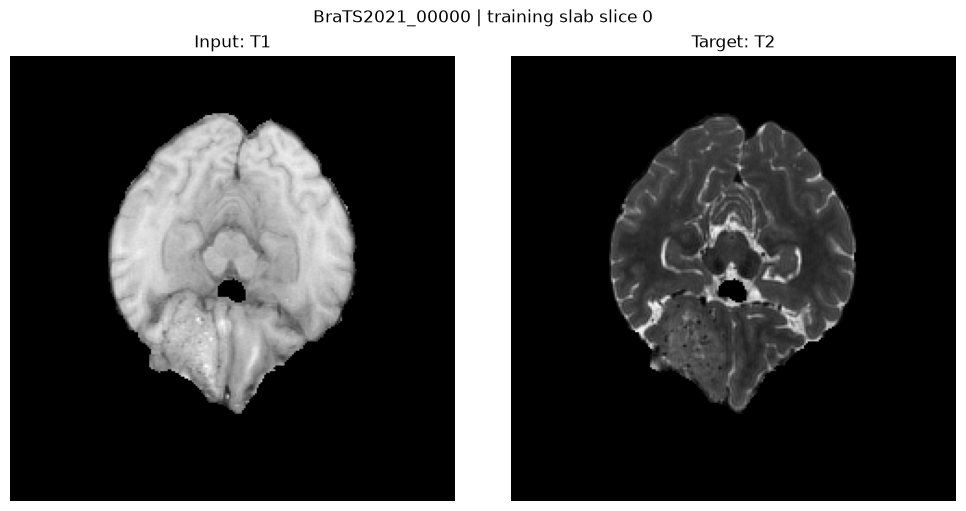

In [4]:
modality_names = {0: "FLAIR", 1: "T1", 2: "T1CE", 3: "T2"}
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for ax, image, title in zip(
    axes,
    (input_image, target_image),
    (f"Input: {modality_names[INPUT_MODALITY]}", f"Target: {modality_names[TARGET_MODALITY]}"),
):
    # Shared [0,1] display scale preserves the actual training contrast.
    display_image = ((image.float() + 1) / 2).clamp(0, 1).numpy()
    ax.imshow(display_image.T, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"{subject_id} | training slab slice {SLICE_INDEX}")
plt.show()

Both panels use the same display scale. Transposing both images is for display only.
The existing training normalization uses a shared minimum and maximum across all
four modalities and the sampled slab; no additional per-image contrast adjustment
is applied here. Re-run the loading cell to reproduce the seeded crop, or change
`SEED` / `SLICE_INDEX` to inspect another pair from the same subject.

## Sample the selected pair with the trained checkpoint

The following cells restore the training manager from `best.model`, enable `return_prediction`, and predict the selected slice in one model call at the terminal bridge time. The checkpoint only exists on the server, so run these cells there after setting the paths.

In [5]:
# Paths are relative to the repository root on the training server.
CHECKPOINT_PATH = Path("experiments/brats2021.exp/checkpoints/last.model")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert CHECKPOINT_PATH.is_file(), f"Checkpoint not found: {CHECKPOINT_PATH.resolve()}"
print(f"Checkpoint: {CHECKPOINT_PATH.resolve()}")
print(f"Sampling device: {DEVICE}")

Checkpoint: /home/qhe2/Developer/reg-bbrg/experiments/brats2021.exp/checkpoints/last.model
Sampling device: cuda


In [6]:
from torchmanager_core import devices
from reg_bbrg.managers import AdversarialDiffusionManager

# A .model file stores the complete manager, including the model architecture.
manager = AdversarialDiffusionManager.from_checkpoint(
    str(CHECKPOINT_PATH), map_location=devices.CPU
)
manager.reset()
manager.raw_model.return_prediction = True
manager.loss_fn = None
print(f"Loaded checkpoint with {manager.time_steps} diffusion steps")

Loaded checkpoint with 1000 diffusion steps


In [7]:
# Keep the tensor in BCHW layout: one image, one channel, height, width.
condition = pair["input"][SLICE_INDEX:SLICE_INDEX + 1].detach().cpu().float()
reference = pair["target"][SLICE_INDEX:SLICE_INDEX + 1].detach().cpu().float()
assert condition.shape == reference.shape and condition.ndim == 4

from diffusion.data import DiffusionData

model = manager.raw_model.to(DEVICE).eval()
model_input = condition.to(DEVICE)
# At t=T, the bridge input is the source image itself.
terminal_time = torch.full((model_input.shape[0],), model.time_steps, dtype=torch.long, device=DEVICE)
with torch.inference_mode():
    output = model(DiffusionData(model_input, terminal_time, condition=model_input))
    sample = output["target"].detach().cpu()
assert sample.shape == reference.shape, (sample.shape, reference.shape)
assert torch.isfinite(sample).all(), "The generated image contains non-finite values."
print(f"Generated tensor shape: {tuple(sample.shape)}")

Sampling loop time step: 100%|██████████| 1000/1000 [01:46<00:00,  9.35it/s]


Generated tensor shape: (1, 1, 240, 240)


In [8]:
# Convert the model's [-1, 1] convention to [0, 1] for display and summary metrics.
to_display = lambda tensor: ((tensor.float() + 1) / 2).clamp(0, 1)
condition_01 = to_display(condition[0, 0])
reference_01 = to_display(reference[0, 0])
sample_01 = to_display(sample[0, 0])
absolute_error = (sample_01 - reference_01).abs()
mse = torch.mean((sample_01 - reference_01) ** 2)
mae = absolute_error.mean()
psnr = torch.tensor(float("inf")) if mse == 0 else -10 * torch.log10(mse)
print(f"MAE [0, 1]: {mae.item():.4f}")
print(f"PSNR: {psnr.item():.2f} dB")

MAE [0, 1]: 0.0110
PSNR: 32.97 dB


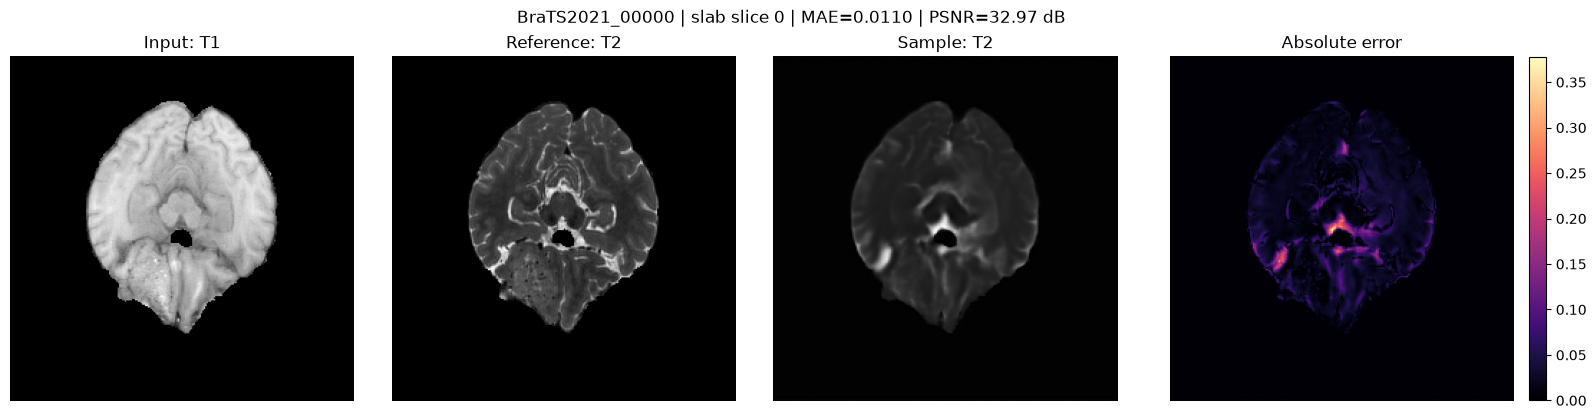

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
panels = (
    (condition_01, f"Input: {modality_names[INPUT_MODALITY]}", "gray", 0, 1),
    (reference_01, f"Reference: {modality_names[TARGET_MODALITY]}", "gray", 0, 1),
    (sample_01, f"Sample: {modality_names[TARGET_MODALITY]}", "gray", 0, 1),
    (absolute_error, "Absolute error", "magma", 0, 1),
)
for ax, (image, title, cmap, vmin, vmax) in zip(axes, panels):
    rendered = ax.imshow(image.numpy().T, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(rendered, ax=axes[-1], fraction=0.046, pad=0.04)
fig.suptitle(
    f"{subject_id} | slab slice {SLICE_INDEX} | MAE={mae.item():.4f} | PSNR={psnr.item():.2f} dB"
)
plt.show()